<a href="https://colab.research.google.com/github/Silva-DTS/Statistical-Learning-e23379/blob/main/Kalman_filter_assignment_Answers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q. Analytical Derivation

Consider the filter model
\begin{align*}
x^{-}_k &= A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}, \\
y^{-}_k &= H_k\,x^{-}_k + z_k,
\end{align*}
where
$$x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1}),$$

Answer the followings:

1. Show that
$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-),$$
where
$$m_k^- = A_{k-1}m_{k-1},$$
and
$$
P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T.
$$

2. Show that
$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m).$$

3. Show that
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right).$$

4. Show that
$$x^{+}_k\triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) \sim \mathscr{N}(m_k, P_k),$$
where the updated mean $m_k$ and updated covariance $P_k$ are given by:
\begin{align*}
K_k &\triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}, \\
m_k &= m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-), \\
P_k &= (I - K_k H_k) P_k^-.
\end{align*}

5. Find
$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}]$  and
$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$.

### Answer

#### 1.

The prediction equation of the state is

$$
x_k^- = A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1},
$$

where

$$
x_{k-1}^+ \sim \mathcal{N}(m_{k-1},P_{k-1}),
$$

and

$$
w_{k-1}\sim\mathcal{N}(0,\Sigma_p).
$$

Since \(x_{k-1}^+\) and \(w_{k-1}\) are independent Gaussian random vectors, any linear combination of them is also Gaussian. Therefore,

$$
x_k^- \sim \mathcal{N}(m_k^-,P_k^-).
$$

The predicted mean is

$$
m_k^-=\mathbb{E}[x_k^-].
$$

Substituting the state equation,

$$
m_k^-=\mathbb{E}[A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1}].
$$

Using the linearity of expectation,

$$
m_k^-
=
A_{k-1}\mathbb{E}[x_{k-1}^+]
+
G_{k-1}\mathbb{E}[w_{k-1}].
$$

Since

$$
\mathbb{E}[w_{k-1}]=0,
$$

we obtain

$$
m_k^-
=
A_{k-1}m_{k-1}.
$$

Hence,

$$
\boxed{
m_k^- = A_{k-1}m_{k-1}.
}
$$

The predicted covariance is

$$
P_k^-=\operatorname{Var}(x_k^-).
$$

Substituting the state equation,

$$
P_k^-
=
\operatorname{Var}
(A_{k-1}x_{k-1}^+
+
G_{k-1}w_{k-1}).
$$

Since \(x_{k-1}^+\) and \(w_{k-1}\) are independent,

$$
\operatorname{Cov}(x_{k-1}^+,w_{k-1})=0.
$$

Therefore,

$$
P_k^-
=
A_{k-1}
\operatorname{Var}(x_{k-1}^+)
A_{k-1}^T
+
G_{k-1}
\operatorname{Var}(w_{k-1})
G_{k-1}^T.
$$

Using

$$
\operatorname{Var}(x_{k-1}^+)=P_{k-1},
$$

and

$$
\operatorname{Var}(w_{k-1})=\Sigma_p,
$$

gives

$$
P_k^-
=
A_{k-1}P_{k-1}A_{k-1}^T
+
G_{k-1}\Sigma_pG_{k-1}^T.
$$

Hence,

$$
\boxed{
P_k^-
=
A_{k-1}P_{k-1}A_{k-1}^T
+
G_{k-1}\Sigma_pG_{k-1}^T.
}
$$

Therefore,

$$
\boxed{
x_k^-
\sim
\mathcal{N}(m_k^-,P_k^-).
}
$$



#### 2.

The measurement equation is

$$
y_k^-
=
H_kx_k^-
+
z_k,
$$

where

$$
z_k
\sim
\mathcal{N}(0,\Sigma_m),
$$

and \(x_k^-\) and \(z_k\) are independent.

Since a linear transformation of Gaussian random variables remains Gaussian,

$$
y_k^-
\sim
\mathcal{N}(\mu_y,\Sigma_y).
$$

The mean of the measurement is

$$
\mu_y
=
\mathbb{E}[y_k^-].
$$

Substituting the measurement equation,

$$
\mu_y
=
\mathbb{E}[H_kx_k^-+z_k].
$$

Applying the linearity of expectation,

$$
\mu_y
=
H_k\mathbb{E}[x_k^-]
+
\mathbb{E}[z_k].
$$

Since

$$
\mathbb{E}[z_k]=0,
$$

we obtain

$$
\mu_y
=
H_km_k^-.
$$

Hence,

$$
\boxed{
\mathbb{E}[y_k^-]
=
H_km_k^-.
}
$$

The covariance of the measurement is

$$
\Sigma_y
=
\operatorname{Var}(y_k^-).
$$

Substituting the measurement equation,

$$
\Sigma_y
=
\operatorname{Var}
(H_kx_k^-+z_k).
$$

Since \(x_k^-\) and \(z_k\) are independent,

$$
\Sigma_y
=
H_k
\operatorname{Var}(x_k^-)
H_k^T
+
\operatorname{Var}(z_k).
$$

Using

$$
\operatorname{Var}(x_k^-)=P_k^-,
$$

and

$$
\operatorname{Var}(z_k)=\Sigma_m,
$$

gives

$$
\Sigma_y
=
H_kP_k^-H_k^T
+
\Sigma_m.
$$

Hence,

$$
\boxed{
\operatorname{Var}(y_k^-)
=
H_kP_k^-H_k^T
+
\Sigma_m.
}
$$

Therefore,

$$
\boxed{
y_k^-
\sim
\mathcal{N}
\left(
H_km_k^-,
H_kP_k^-H_k^T+\Sigma_m
\right).
}
$$


### 3.

From the state and measurement equations,

$$
x_k^- \sim \mathcal{N}(m_k^-,P_k^-),
$$

and

$$
y_k^- = H_kx_k^- + z_k,
$$

where

$$
z_k \sim \mathcal{N}(0,\Sigma_m),
$$

and \(x_k^-\) and \(z_k\) are mutually independent.

Since \(y_k^-\) is a linear transformation of \(x_k^-\), the vector

$$
\begin{pmatrix}
x_k^-\\
y_k^-
\end{pmatrix}
$$

is jointly Gaussian.

The mean vector is

$$
\mathbb{E}
\left[
\begin{pmatrix}
x_k^-\\
y_k^-
\end{pmatrix}
\right]
=
\begin{pmatrix}
\mathbb{E}[x_k^-]\\
\mathbb{E}[y_k^-]
\end{pmatrix}.
$$

Using the results obtained in Parts 1 and 2,

$$
\mathbb{E}[x_k^-]=m_k^-,
$$

and

$$
\mathbb{E}[y_k^-]=H_km_k^-.
$$

Hence,

$$
\boxed{
\mathbb{E}
\left[
\begin{pmatrix}
x_k^-\\
y_k^-
\end{pmatrix}
\right]
=
\begin{pmatrix}
m_k^-\\
H_km_k^-
\end{pmatrix}.
}
$$

The covariance matrix is

$$
\operatorname{Var}
\left(
\begin{pmatrix}
x_k^-\\
y_k^-
\end{pmatrix}
\right)
=
\begin{pmatrix}
\operatorname{Var}(x_k^-)
&
\operatorname{Cov}(x_k^-,y_k^-)
\\
\operatorname{Cov}(y_k^-,x_k^-)
&
\operatorname{Var}(y_k^-)
\end{pmatrix}.
$$

The upper-left block is

$$
\operatorname{Var}(x_k^-)=P_k^-.
$$

The upper-right block is

$$
\operatorname{Cov}(x_k^-,y_k^-)
=
\operatorname{Cov}
(x_k^-,H_kx_k^-+z_k).
$$

Since

$$
\operatorname{Cov}(x_k^-,z_k)=0,
$$

we obtain

$$
\operatorname{Cov}(x_k^-,y_k^-)
=
\operatorname{Cov}(x_k^-,H_kx_k^-).
$$

Using the covariance property,

$$
\operatorname{Cov}(X,AX)=\operatorname{Var}(X)A^T,
$$

gives

$$
\boxed{
\operatorname{Cov}(x_k^-,y_k^-)
=
P_k^-H_k^T.
}
$$

Similarly,

$$
\boxed{
\operatorname{Cov}(y_k^-,x_k^-)
=
H_kP_k^-.
}
$$

From Part 2,

$$
\boxed{
\operatorname{Var}(y_k^-)
=
H_kP_k^-H_k^T+\Sigma_m.
}
$$

Therefore, the covariance matrix becomes

$$
\boxed{
\begin{pmatrix}
P_k^- &
P_k^-H_k^T
\\
H_kP_k^- &
H_kP_k^-H_k^T+\Sigma_m
\end{pmatrix}.
}
$$

Hence,

$$
\boxed{
\begin{pmatrix}
x_k^-\\
y_k^-
\end{pmatrix}
\sim
\mathcal{N}
\left(
\begin{pmatrix}
m_k^-\\
H_km_k^-
\end{pmatrix},
\begin{pmatrix}
P_k^- &
P_k^-H_k^T
\\
H_kP_k^- &
H_kP_k^-H_k^T+\Sigma_m
\end{pmatrix}
\right).
}
$$



#### 4.

From Part 3,

$$
\begin{pmatrix}
x_k^-\\
y_k^-
\end{pmatrix}
$$

is jointly Gaussian.

For a jointly Gaussian random vector,

$$
\begin{pmatrix}
x\\
y
\end{pmatrix}
\sim
\mathcal{N}
\left(
\begin{pmatrix}
\mu_x\\
\mu_y
\end{pmatrix},
\begin{pmatrix}
\Sigma_{xx} &
\Sigma_{xy}
\\
\Sigma_{yx} &
\Sigma_{yy}
\end{pmatrix}
\right),
$$

the conditional distribution is

$$
x|y
\sim
\mathcal{N}
\left(
\mu_x+
\Sigma_{xy}
\Sigma_{yy}^{-1}
(y-\mu_y),
\,
\Sigma_{xx}
-
\Sigma_{xy}
\Sigma_{yy}^{-1}
\Sigma_{yx}
\right).
$$

Comparing this with the joint distribution obtained in Part 3,

$$
\mu_x=m_k^-,
$$

$$
\mu_y=H_km_k^-,
$$

$$
\Sigma_{xy}=P_k^-H_k^T,
$$

$$
\Sigma_{yy}=H_kP_k^-H_k^T+\Sigma_m.
$$

Therefore, the Kalman gain is

$$
\boxed{
K_k
=
P_k^-H_k^T
(H_kP_k^-H_k^T+\Sigma_m)^{-1}.
}
$$

Substituting into the conditional mean formula,

$$
m_k
=
m_k^-
+
K_k
\left(
y_k^{\mathrm{obs}}
-
H_km_k^-
\right).
$$

Hence,

$$
\boxed{
m_k
=
m_k^-
+
K_k
\left(
y_k^{\mathrm{obs}}
-
H_km_k^-
\right).
}
$$

Similarly, the conditional covariance is

$$
P_k
=
P_k^-
-
P_k^-H_k^T
(H_kP_k^-H_k^T+\Sigma_m)^{-1}
H_kP_k^-.
$$

Using the definition of the Kalman gain,

$$
K_k
=
P_k^-H_k^T
(H_kP_k^-H_k^T+\Sigma_m)^{-1},
$$

the covariance simplifies to

$$
\boxed{
P_k
=
(I-K_kH_k)P_k^-.
}
$$

Therefore,

$$
\boxed{
x_k^+
=
(x_k^- \mid y_k^-=y_k^{\mathrm{obs}})
\sim
\mathcal{N}(m_k,P_k).
}
$$



#### 5.

From Part 4, the posterior (conditional) distribution of the state is

$$
x_k^+
=
\left(x_k^- \mid y_k^- = y_k^{\mathrm{obs}}\right)
\sim
\mathcal{N}(m_k,P_k),
$$

where

$$
m_k
=
m_k^-
+
K_k
\left(
y_k^{\mathrm{obs}}
-
H_km_k^-
\right),
$$

and

$$
P_k
=
(I-K_kH_k)P_k^-.
$$

For a Gaussian random vector,

$$
X|Y
\sim
\mathcal{N}(\mu,\Sigma),
$$

the conditional expectation is the mean of the conditional distribution, and the conditional variance is the covariance matrix of the conditional distribution.

Hence,

$$
\mathbb{E}
\left[
x_k^-
\mid
y_k^-
=
y_k^{\mathrm{obs}}
\right]
=
m_k.
$$

Substituting the expression for the updated mean,

$$
\boxed{
\mathbb{E}
\left[
x_k^-
\mid
y_k^-
=
y_k^{\mathrm{obs}}
\right]
=
m_k^-
+
K_k
\left(
y_k^{\mathrm{obs}}
-
H_km_k^-
\right).
}
$$

Similarly,

$$
\operatorname{Var}
\left(
x_k^-
\mid
y_k^-
=
y_k^{\mathrm{obs}}
\right)
=
P_k.
$$

Substituting the expression for the updated covariance,

$$
\boxed{
\operatorname{Var}
\left(
x_k^-
\mid
y_k^-
=
y_k^{\mathrm{obs}}
\right)
=
(I-K_kH_k)P_k^-.
}
$$

Therefore,

$$
\boxed{
\mathbb{E}
\left[
x_k^-
\mid
y_k^-
=
y_k^{\mathrm{obs}}
\right]
=
m_k^-
+
K_k
\left(
y_k^{\mathrm{obs}}
-
H_km_k^-
\right)
}
$$

and

$$
\boxed{
\operatorname{Var}
\left(
x_k^-
\mid
y_k^-
=
y_k^{\mathrm{obs}}
\right)
=
(I-K_kH_k)P_k^-.
}
$$

Hence proved.

# Q. 1-D Example

Consider the scalar linear-Gaussian filter model
\begin{aligned}
x^-_k &= a\,x^+_{k-1} + w_{k-1},\qquad w_{k-1}\sim\mathscr N(0,q),\\
y^-_k &= h\,x^-_k + z_k,\qquad\;\;\;\; z_k\sim\mathscr N(0,r),
\end{aligned}
with prior $x_0\sim \mathscr{N}(m_0,P_0)$. Define $Y_{k}=\{y^{\mathrm{obs}}_1,\dots,y^{\mathrm{obs}}_{k}\}$.

Answer the following:

1. Show that
\begin{aligned}
m_k^- &= a\,m_{k-1},\\
P_k^- &= a^2 P_{k-1} + q.
\end{aligned}

2. Show that
\begin{aligned}
m_k &= m_k^- + K_k\,v_k
= m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr),\\
P_k &= (1 - K_k h)\,P_k^-
= \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^- .
\end{aligned}

3. Show that the predictive measurement distribution (before seeing $y_k$):
\begin{align*}
p(y^-_k | Y_{k-1})=\mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr).
\end{align*}

4. Show that the posterior-predictive measurement distribution (after filtering on $y_k$):
\begin{align*}
p(y^-_k\mid Y_k)=\mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr).
\end{align*}

5. For suitable numerical values for $a,q,h,r$ animate the above to prior distribution and the posterior distribution.

### Answer

#### 1.

The scalar state prediction equation is

$$
x_k^- = ax_{k-1}^+ + w_{k-1},
$$

where

$$
x_{k-1}^+ \sim \mathcal{N}(m_{k-1},P_{k-1}),
$$

and

$$
w_{k-1}\sim\mathcal{N}(0,q).
$$

Since \(x_{k-1}^+\) and \(w_{k-1}\) are independent Gaussian random variables, \(x_k^-\) is also Gaussian.

The predicted mean is

$$
m_k^-=\mathbb{E}[x_k^-].
$$

Substituting the state equation,

$$
m_k^-=\mathbb{E}[ax_{k-1}^+ + w_{k-1}].
$$

Using the linearity of expectation,

$$
m_k^-
=
a\mathbb{E}[x_{k-1}^+]
+
\mathbb{E}[w_{k-1}].
$$

Since

$$
\mathbb{E}[w_{k-1}]=0,
$$

we obtain

$$
m_k^-
=
am_{k-1}.
$$

Hence,

$$
\boxed{
m_k^- = am_{k-1}.
}
$$

The predicted covariance is

$$
P_k^-=\operatorname{Var}(x_k^-).
$$

Substituting the state equation,

$$
P_k^-
=
\operatorname{Var}(ax_{k-1}^+ + w_{k-1}).
$$

Since \(x_{k-1}^+\) and \(w_{k-1}\) are independent,

$$
\operatorname{Cov}(x_{k-1}^+,w_{k-1})=0.
$$

Therefore,

$$
P_k^-
=
a^2\operatorname{Var}(x_{k-1}^+)
+
\operatorname{Var}(w_{k-1}).
$$

Using

$$
\operatorname{Var}(x_{k-1}^+)=P_{k-1},
$$

and

$$
\operatorname{Var}(w_{k-1})=q,
$$

gives

$$
P_k^-
=
a^2P_{k-1}+q.
$$

Hence,

$$
\boxed{
P_k^-
=
a^2P_{k-1}+q.
}
$$


#### 2.

The innovation (measurement residual) is

$$
v_k
=
y_k^{\mathrm{obs}}
-
hm_k^-.
$$

The innovation covariance is

$$
S_k
=
h^2P_k^-+r.
$$

The Kalman gain is

$$
K_k
=
\frac{P_k^-h}{S_k}.
$$

The updated mean is obtained by correcting the predicted mean using the innovation,

$$
m_k
=
m_k^-+K_kv_k.
$$

Substituting the expressions for \(K_k\) and \(v_k\),

$$
m_k
=
m_k^-
+
\frac{P_k^-h}{S_k}
\left(
y_k^{\mathrm{obs}}
-
hm_k^-
\right).
$$

Hence,

$$
\boxed{
m_k
=
m_k^-+K_kv_k
=
m_k^-
+
\frac{P_k^-h}{S_k}
\left(
y_k^{\mathrm{obs}}
-
hm_k^-
\right).
}
$$

The updated covariance is

$$
P_k
=
(1-K_kh)P_k^-.
$$

Substituting the expression for the Kalman gain,

$$
P_k
=
\left(
1-
\frac{P_k^-h}{S_k}h
\right)
P_k^-.
$$

Therefore,

$$
P_k
=
\left(
1-
\frac{P_k^-h^2}{S_k}
\right)
P_k^-.
$$

Hence,

$$
\boxed{
P_k
=
(1-K_kh)P_k^-
=
\left(
1-
\frac{P_k^-h^2}{S_k}
\right)
P_k^-.
}
$$


#### 3.

The measurement equation is

$$
y_k^- = hx_k^- + z_k,
$$

where

$$
z_k \sim \mathcal{N}(0,r),
$$

and \(x_k^-\) and \(z_k\) are independent.

From Part 1,

$$
x_k^- \sim \mathcal{N}(m_k^-,P_k^-).
$$

Since \(y_k^-\) is a linear transformation of Gaussian random variables,

$$
y_k^- \sim \mathcal{N}(\mu_y,\sigma_y^2).
$$

The mean of the predictive measurement is

$$
\mu_y
=
\mathbb{E}[y_k^-].
$$

Substituting the measurement equation,

$$
\mu_y
=
\mathbb{E}[hx_k^-+z_k].
$$

Using the linearity of expectation,

$$
\mu_y
=
h\mathbb{E}[x_k^-]
+
\mathbb{E}[z_k].
$$

Since

$$
\mathbb{E}[z_k]=0,
$$

we obtain

$$
\mu_y
=
hm_k^-.
$$

The variance of the predictive measurement is

$$
\sigma_y^2
=
\operatorname{Var}(y_k^-).
$$

Substituting the measurement equation,

$$
\sigma_y^2
=
\operatorname{Var}(hx_k^-+z_k).
$$

Since \(x_k^-\) and \(z_k\) are independent,

$$
\sigma_y^2
=
h^2\operatorname{Var}(x_k^-)
+
\operatorname{Var}(z_k).
$$

Using

$$
\operatorname{Var}(x_k^-)=P_k^-,
$$

and

$$
\operatorname{Var}(z_k)=r,
$$

gives

$$
\sigma_y^2
=
h^2P_k^-+r.
$$

Therefore,

$$
\boxed{
p(y_k^-|Y_{k-1})
=
\mathcal{N}
\left(
hm_k^-,
h^2P_k^-+r
\right).
}
$$



#### 4.

After incorporating the observation \(y_k^{\mathrm{obs}}\), the updated state distribution is

$$
x_k^+
\sim
\mathcal{N}(m_k,P_k).
$$

The posterior-predictive measurement is obtained from

$$
y_k^- = hx_k^+ + z_k.
$$

Since \(x_k^+\) and \(z_k\) are independent Gaussian random variables,

$$
y_k^-|Y_k
\sim
\mathcal{N}(\mu_{y|k},\sigma_{y|k}^2).
$$

The posterior-predictive mean is

$$
\mu_{y|k}
=
\mathbb{E}[y_k^-|Y_k].
$$

Substituting the measurement equation,

$$
\mu_{y|k}
=
\mathbb{E}[hx_k^+ + z_k].
$$

Using the linearity of expectation,

$$
\mu_{y|k}
=
h\mathbb{E}[x_k^+]
+
\mathbb{E}[z_k].
$$

Since

$$
\mathbb{E}[x_k^+]=m_k,
$$

and

$$
\mathbb{E}[z_k]=0,
$$

we obtain

$$
\mu_{y|k}
=
hm_k.
$$

The posterior-predictive variance is

$$
\sigma_{y|k}^2
=
\operatorname{Var}(y_k^-|Y_k).
$$

Substituting the measurement equation,

$$
\sigma_{y|k}^2
=
\operatorname{Var}(hx_k^+ + z_k).
$$

Since \(x_k^+\) and \(z_k\) are independent,

$$
\sigma_{y|k}^2
=
h^2\operatorname{Var}(x_k^+)
+
\operatorname{Var}(z_k).
$$

Using

$$
\operatorname{Var}(x_k^+)=P_k,
$$

and

$$
\operatorname{Var}(z_k)=r,
$$

gives

$$
\sigma_{y|k}^2
=
h^2P_k+r.
$$

Therefore,

$$
\boxed{
p(y_k^-|Y_k)
=
\mathcal{N}
\left(
hm_k,
h^2P_k+r
\right).
}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.stats import norm
from IPython.display import HTML

# -----------------------------
# Model Parameters
# -----------------------------
a = 1.0          # State transition coefficient
h = 1.0          # Measurement coefficient
q = 0.2          # Process noise variance
r = 1.0          # Measurement noise variance

# Initial estimate
m = 0.0
P = 1.0

# Number of time steps
N = 30

# -----------------------------
# Generate True State and Measurements
# -----------------------------
np.random.seed(42)

x_true = np.zeros(N)
y_obs = np.zeros(N)

x_true[0] = np.random.normal(m, np.sqrt(P))
y_obs[0] = h * x_true[0] + np.random.normal(0, np.sqrt(r))

for k in range(1, N):
    x_true[k] = a * x_true[k-1] + np.random.normal(0, np.sqrt(q))
    y_obs[k] = h * x_true[k] + np.random.normal(0, np.sqrt(r))

# -----------------------------
# Kalman Filter
# -----------------------------
prior_mean = []
prior_var = []

posterior_mean = []
posterior_var = []

for k in range(N):

    # Prediction
    m_pred = a * m
    P_pred = a**2 * P + q

    prior_mean.append(m_pred)
    prior_var.append(P_pred)

    # Innovation
    S = h**2 * P_pred + r
    K = P_pred * h / S
    v = y_obs[k] - h * m_pred

    # Update
    m = m_pred + K * v
    P = (1 - K * h) * P_pred

    posterior_mean.append(m)
    posterior_var.append(P)

# -----------------------------
# Animation
# -----------------------------
fig, ax = plt.subplots(figsize=(8,5))

x = np.linspace(-6,6,500)

def animate(i):

    ax.clear()

    prior_pdf = norm.pdf(
        x,
        prior_mean[i],
        np.sqrt(prior_var[i])
    )

    posterior_pdf = norm.pdf(
        x,
        posterior_mean[i],
        np.sqrt(posterior_var[i])
    )

    ax.plot(
        x,
        prior_pdf,
        label='Prior Distribution',
        linewidth=2
    )

    ax.plot(
        x,
        posterior_pdf,
        label='Posterior Distribution',
        linewidth=2
    )

    ax.axvline(
        x_true[i],
        linestyle='--',
        label='True State'
    )

    ax.axvline(
        y_obs[i],
        linestyle=':',
        label='Measurement'
    )

    ax.set_xlim(-6,6)
    ax.set_ylim(0,1.2)

    ax.set_xlabel("State")
    ax.set_ylabel("Probability Density")

    ax.set_title(f"Kalman Filter (Step {i+1})")

    ax.legend(loc="upper right")
    ax.grid(True)

ani = FuncAnimation(
    fig,
    animate,
    frames=N,
    interval=700
)

plt.close(fig)

HTML(ani.to_jshtml())

# Q. 2D-Position Estimation

## Part A

Consider a two-dimensional constant-velocity dynamical system. The hidden state at time step $k$ is

$$
x_k =
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where $(p_x(k),p_y(k))$ denote the position components and $(v_x(k),v_y(k))$ denote the velocity components.

The measurement consists only of the two position components:

$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The linear Gaussian state-space filter model is

$$
x^-_k = A x^+_{k-1} + G w_{k-1},
$$

$$
y^-_k = Hx^+_k + z_k,
$$

where

$$
w_{k-1} \sim \mathscr{N}(0,\Sigma_p),
\qquad
z_k \sim \mathscr{N}(0,\Sigma_m).
$$

The process noise sequence $w_k$, measurement noise sequence $z_k$, and the initial state are assumed mutually independent.

Show that:

$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
$$



$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix},
$$

and

$$
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$

### Answer

The hidden state vector is

$$
x_k =
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where

- \(p_x(k)\) and \(p_y(k)\) are the position coordinates,
- \(v_x(k)\) and \(v_y(k)\) are the velocity components.

The system is assumed to follow a **constant-velocity model**, which means the velocity remains constant during each sampling interval \(\Delta t\). Therefore,

$$
v_x(k)=v_x(k-1),
$$

$$
v_y(k)=v_y(k-1).
$$

Using the kinematic equations,

$$
p_x(k)=p_x(k-1)+v_x(k-1)\Delta t,
$$

$$
p_y(k)=p_y(k-1)+v_y(k-1)\Delta t.
$$

Combining these four equations into matrix form,

$$
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
p_x(k-1)\\
p_y(k-1)\\
v_x(k-1)\\
v_y(k-1)
\end{bmatrix}.
$$

Hence, the state transition matrix is

$$
\boxed{
A=
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix}.
}
$$


The measurement vector contains only the position components,

$$
y_k=
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

Since only the position is measured,

$$
p_x^{\mathrm{meas}}(k)=p_x(k),
$$

$$
p_y^{\mathrm{meas}}(k)=p_y(k).
$$

The measurement equation can therefore be written as

$$
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix}
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix}
+
z_k.
$$

Hence, the observation matrix is

$$
\boxed{
H=
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix}.
}
$$



The process noise represents unknown acceleration acting on the system.

Let

$$
w_{k-1}=
\begin{bmatrix}
a_x(k-1)\\
a_y(k-1)
\end{bmatrix},
$$

where \(a_x\) and \(a_y\) are the acceleration disturbances.

Using the equations of uniformly accelerated motion,

$$
p_x(k)
=
p_x(k-1)
+
v_x(k-1)\Delta t
+
\frac12 a_x(k-1)\Delta t^2,
$$

$$
p_y(k)
=
p_y(k-1)
+
v_y(k-1)\Delta t
+
\frac12 a_y(k-1)\Delta t^2,
$$

$$
v_x(k)
=
v_x(k-1)
+
a_x(k-1)\Delta t,
$$

$$
v_y(k)
=
v_y(k-1)
+
a_y(k-1)\Delta t.
$$

Collecting the acceleration terms,

$$
\begin{bmatrix}
\frac12\Delta t^2a_x\\
\frac12\Delta t^2a_y\\
\Delta ta_x\\
\Delta ta_y
\end{bmatrix}
=
\begin{bmatrix}
\frac12\Delta t^2 & 0\\
0 & \frac12\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}
\begin{bmatrix}
a_x\\
a_y
\end{bmatrix}.
$$

Therefore,

$$
\boxed{
G=
\begin{bmatrix}
\frac12\Delta t^2 & 0\\
0 & \frac12\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
}
$$

Hence, the constant-velocity state-space model is

$$
\boxed{
A=
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
}
$$

$$
\boxed{
H=
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix},
}
$$

and

$$
\boxed{
G=
\begin{bmatrix}
\frac12\Delta t^2 & 0\\
0 & \frac12\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
}
$$

Thus, the required state transition matrix, observation matrix, and process noise input matrix have been derived.

## Part B

Develop a python based method to filter a sequence of noisy GPS obtained position meaurements.

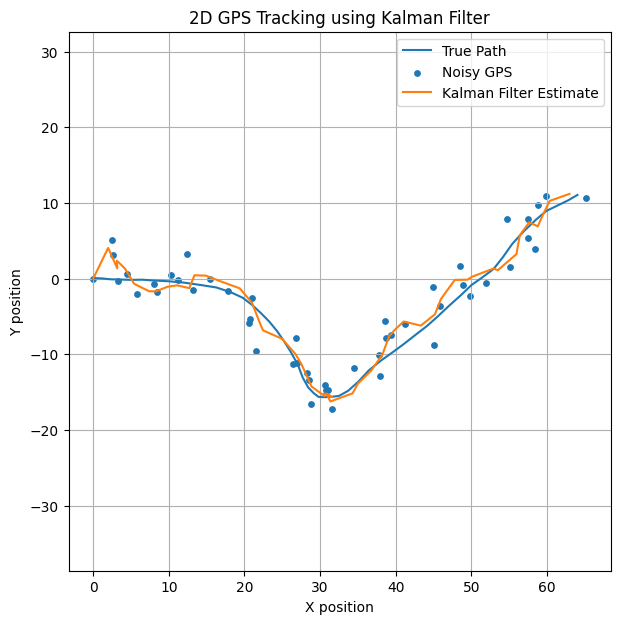

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameters
# -----------------------------
dt = 1.0

# State: [px, py, vx, vy]^T
A = np.array([
    [1, 0, dt, 0],
    [0, 1, 0, dt],
    [0, 0, 1,  0],
    [0, 0, 0,  1]
])

H = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0]
])

G = np.array([
    [0.5*dt**2, 0],
    [0, 0.5*dt**2],
    [dt, 0],
    [0, dt]
])

# Noise covariances
q = 0.1
r = 5.0

Q = q * np.eye(2)      # process noise (acceleration)
R = r * np.eye(2)      # GPS noise

# -----------------------------
# Simulate True trajectory + GPS measurements
# -----------------------------
np.random.seed(0)

N = 50

x_true = np.zeros((4, N))
z_meas = np.zeros((2, N))

for k in range(1, N):
    accel = np.random.multivariate_normal([0, 0], Q)

    x_true[:, k] = A @ x_true[:, k-1] + G @ accel

    noise = np.random.multivariate_normal([0, 0], R)
    z_meas[:, k] = H @ x_true[:, k] + noise

# -----------------------------
# Kalman Filter Initialization
# -----------------------------
x_est = np.zeros((4, N))
P = np.eye(4) * 10

x_est[:, 0] = [0, 0, 0, 0]

# -----------------------------
# Kalman Filter Loop
# -----------------------------
for k in range(1, N):

    # Prediction
    x_pred = A @ x_est[:, k-1]
    P_pred = A @ P @ A.T + G @ Q @ G.T

    # Innovation
    y = z_meas[:, k] - H @ x_pred
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)

    # Update
    x_est[:, k] = x_pred + K @ y
    P = (np.eye(4) - K @ H) @ P_pred

# -----------------------------
# Plot Results
# -----------------------------
plt.figure(figsize=(7,7))

plt.plot(x_true[0], x_true[1], label="True Path")
plt.scatter(z_meas[0], z_meas[1], label="Noisy GPS", s=15)
plt.plot(x_est[0], x_est[1], label="Kalman Filter Estimate")

plt.xlabel("X position")
plt.ylabel("Y position")
plt.legend()
plt.title("2D GPS Tracking using Kalman Filter")
plt.grid()
plt.axis("equal")

plt.show()